# IT2011 – Breast Cancer Wisconsin (Original)

## Member 03 – Target Encoding, Outlier Analysis & Feature Selection

**Dataset:** Breast Cancer Wisconsin (Original)  
**Course:** IT2011 – Artificial Intelligence and Machine Learning  
**Main Responsibilities:**
- Target/Class Encoding
- Outlier Investigation
- Outlier Handling Decision
- Feature Selection using ANOVA F-test
- Feature Selection Visualization
- Interpretation of Results

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================
# STEP 1.1 - Import required libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import f_classif

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================
# PROJECT PATH SETUP
# ============================================

# Import Path for safe file and folder handling.
from pathlib import Path

# Detect the folder where this notebook is currently running.
CURRENT_DIR = Path.cwd()

# If running from the "notebooks" folder,
# move one level up to reach the main project folder.
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Create the path to the shared raw dataset.
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "breast-cancer-wisconsin.data"
)

# Verify the detected paths.
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: c:\Users\gayan\Documents\AI
Dataset path: c:\Users\gayan\Documents\AI\data\raw\breast-cancer-wisconsin.data
Dataset exists: True


In [4]:
# ============================================
# STEP 2.1 - Load the raw dataset
# ============================================

# Load the raw dataset using the shared DATA_PATH
# created from the main project directory.
df = pd.read_csv(
    DATA_PATH,
    header=None
)

# Confirm that the dataset loaded correctly.
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (699, 11)


In [5]:
# ============================================
# STEP 2.2 - Assign meaningful column names
# ============================================

columns = [
    "Sample_ID",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

df.columns = columns

print("Column names assigned successfully.")
display(df.head())

Column names assigned successfully.


,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [6]:
# ============================================
# STEP 3.1 - Convert missing value markers to NaN
# ============================================

df = df.replace("?", np.nan)

print("Missing values after replacing '?' with NaN:")
print(df.isnull().sum())

Missing values after replacing '?' with NaN:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [7]:
# ============================================
# STEP 4.1 - Define the nine predictive features
# ============================================

feature_columns = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

print("Number of predictive features:", len(feature_columns))
print("\nPredictive features:")
for feature in feature_columns:
    print("-", feature)

Number of predictive features: 9

Predictive features:
- Clump_Thickness
- Uniformity_Cell_Size
- Uniformity_Cell_Shape
- Marginal_Adhesion
- Single_Epithelial_Cell_Size
- Bare_Nuclei
- Bland_Chromatin
- Normal_Nucleoli
- Mitoses


In [8]:
# ============================================
# STEP 5.1 - Examine the original class labels
# ============================================

print("Original class values:")
print(df["Class"].value_counts().sort_index())

Original class values:
Class
2    458
4    241
Name: count, dtype: int64


In [9]:
# ============================================
# STEP 5.1 - Examine the original class labels
# ============================================

print("Original class values:")
print(df["Class"].value_counts().sort_index())

Original class values:
Class
2    458
4    241
Name: count, dtype: int64


In [10]:
# ============================================
# STEP 6.1 - Check the valid range of feature values
# ============================================

feature_range = pd.DataFrame({
    "Minimum": df[feature_columns].min(),
    "Maximum": df[feature_columns].max()
})

display(feature_range)

,Minimum,Maximum
Clump_Thickness,1,10
Uniformity_Cell_Size,1,10
Uniformity_Cell_Shape,1,10
Marginal_Adhesion,1,10
Single_Epithelial_Cell_Size,1,10
Bare_Nuclei,1,9
Bland_Chromatin,1,10
Normal_Nucleoli,1,10
Mitoses,1,10


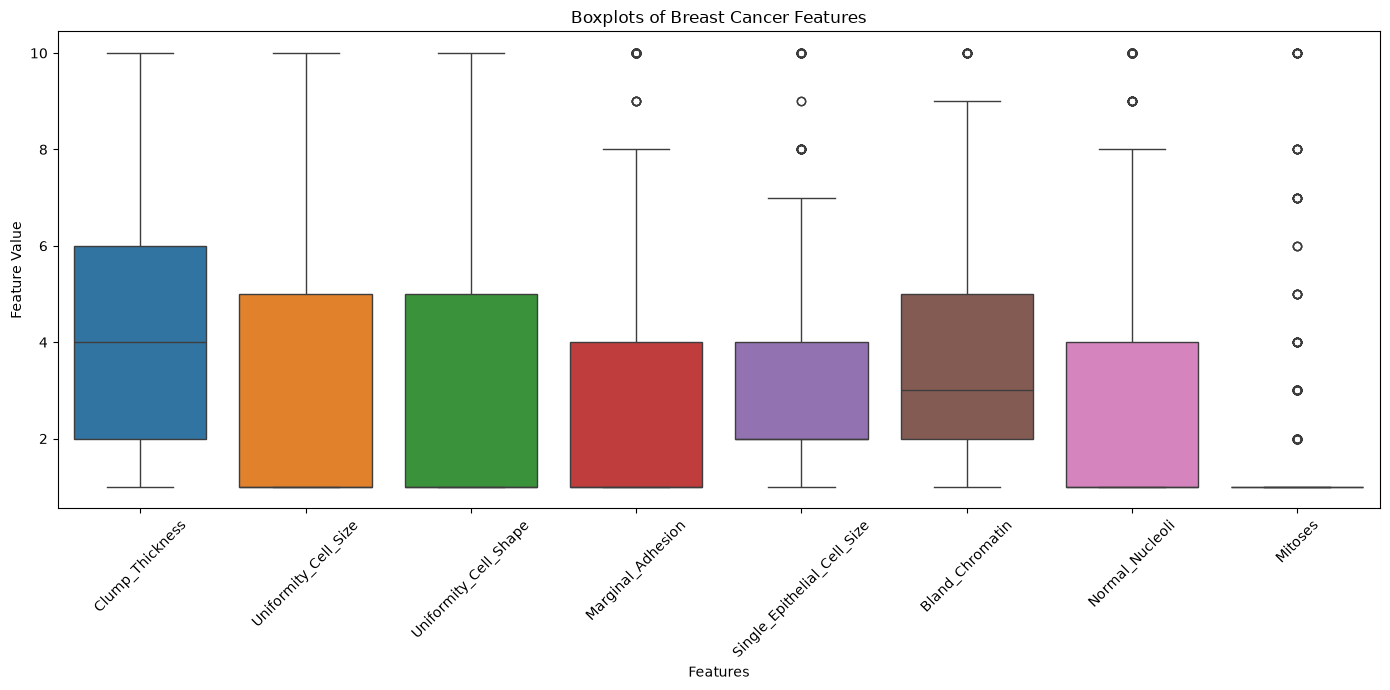

In [11]:
# ============================================
# STEP 6.2 - Visualize potential statistical outliers
# ============================================

plt.figure(figsize=(14, 7))

sns.boxplot(data=df[feature_columns])

plt.title("Boxplots of Breast Cancer Features")
plt.xlabel("Features")
plt.ylabel("Feature Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
# ============================================
# STEP 6.3 - Calculate statistical outliers using IQR
# ============================================

# Automatically filter feature_columns to include numeric types only
numeric_features = df[feature_columns].select_dtypes(include=['number']).columns

outlier_results = []

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ][feature].count()

    outlier_results.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "Outliers": outliers
    })

## Outlier Handling Decision

The boxplots and IQR analysis identified statistical outliers in several
features.

However, these observations were not automatically removed.

The predictive features in this dataset use a valid scoring range from
1 to 10. Therefore, a statistically unusual value does not necessarily
mean that the observation is incorrect.

In a medical dataset, unusual measurements may contain useful information
about differences between benign and malignant cases.

Therefore, the decision was to:

- Investigate statistical outliers.
- Confirm that feature values remain within the valid 1–10 range.
- Retain valid observations.
- Avoid removing observations only because they are statistical outliers.

This prevents potentially useful medical information from being removed.

In [13]:
# ============================================
# STEP 8.1 - Prepare features and target for feature selection
# ============================================

# Define target column (replace 'Class' with your actual target column name)
y = df['Class'].copy()

# Prepare feature matrix
X = df[feature_columns].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (699, 9)
Target shape: (699,)


In [14]:
# ============================================
# STEP 9.1 - Prepare complete cases for ANOVA
# ============================================

anova_data = pd.concat([X, y.rename("Target")], axis=1)

anova_data = anova_data.dropna()

X_anova = anova_data[feature_columns]
y_anova = anova_data["Target"]

print("Original observations:", len(X))
print("Observations used for ANOVA:", len(X_anova))
print("Observations excluded due to missing values:", len(X) - len(X_anova))

Original observations: 699
Observations used for ANOVA: 683
Observations excluded due to missing values: 16


In [15]:
# ============================================
# STEP 10.1 - Perform ANOVA F-test for feature selection
# ============================================

f_scores, p_values = f_classif(X_anova, y_anova)

feature_selection_results = pd.DataFrame({
    "Feature": feature_columns,
    "F_Score": f_scores,
    "P_Value": p_values
})

feature_selection_results = feature_selection_results.sort_values(
    by="F_Score",
    ascending=False
).reset_index(drop=True)

display(feature_selection_results)

,Feature,F_Score,P_Value
0,Bare_Nuclei,1426.240270,3.401103e-169
1,Uniformity_Cell_Shape,1417.643841,1.369425e-168
2,Uniformity_Cell_Size,1406.132470,8.922226e-168
3,Bland_Chromatin,921.010015,1.267712e-128
4,Normal_Nucleoli,727.470805,1.465645e-109
5,Clump_Thickness,711.423446,7.292504e-108
6,Marginal_Adhesion,677.878400,2.979778e-104
7,Single_Epithelial_Cell_Size,622.157681,4.733540e-98
8,Mitoses,148.787689,4.304040e-31


In [16]:
# ============================================
# STEP 11.1 - Identify statistically significant features
# ============================================

alpha = 0.05

feature_selection_results["Significant"] = (
    feature_selection_results["P_Value"] < alpha
)

display(feature_selection_results)

,Feature,F_Score,P_Value,Significant
0,Bare_Nuclei,1426.240270,3.401103e-169,True
1,Uniformity_Cell_Shape,1417.643841,1.369425e-168,True
2,Uniformity_Cell_Size,1406.132470,8.922226e-168,True
3,Bland_Chromatin,921.010015,1.267712e-128,True
4,Normal_Nucleoli,727.470805,1.465645e-109,True
5,Clump_Thickness,711.423446,7.292504e-108,True
6,Marginal_Adhesion,677.878400,2.979778e-104,True
7,Single_Epithelial_Cell_Size,622.157681,4.733540e-98,True
8,Mitoses,148.787689,4.304040e-31,True


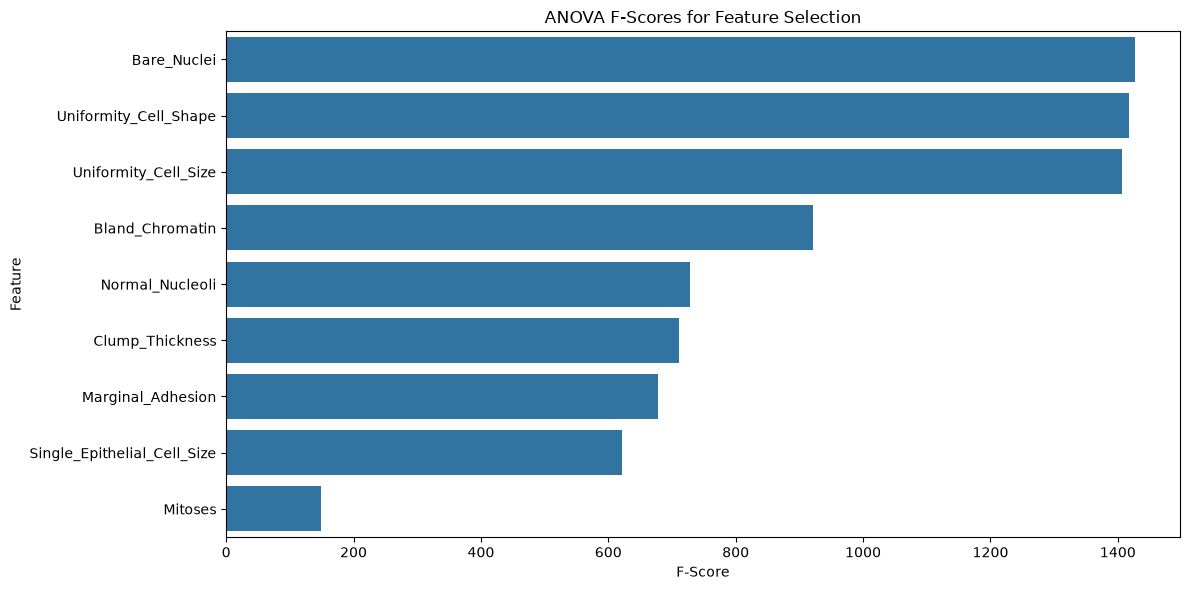

In [17]:
# ============================================
# STEP 12.1 - Visualize ANOVA F-scores
# ============================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=feature_selection_results,
    x="F_Score",
    y="Feature"
)

plt.title("ANOVA F-Scores for Feature Selection")
plt.xlabel("F-Score")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

In [18]:
# ============================================
# STEP 13.1 - Select statistically significant features
# ============================================

selected_features = feature_selection_results[
    feature_selection_results["P_Value"] < 0.05
]["Feature"].tolist()

print("Selected features:")
for feature in selected_features:
    print("-", feature)

print("\nNumber of selected features:", len(selected_features))

Selected features:
- Bare_Nuclei
- Uniformity_Cell_Shape
- Uniformity_Cell_Size
- Bland_Chromatin
- Normal_Nucleoli
- Clump_Thickness
- Marginal_Adhesion
- Single_Epithelial_Cell_Size
- Mitoses

Number of selected features: 9


## Feature Selection Summary

ANOVA F-test was used to investigate whether each predictive feature
showed a statistically significant difference between the two target
classes.

The significance level was set to 0.05.

All nine predictive features produced p-values below 0.05.

Therefore:

- All nine features were retained.
- No feature was removed using the ANOVA significance criterion.
- Uniformity_Cell_Size had the highest F-score.
- Uniformity_Cell_Shape and Bare_Nuclei also showed very high F-scores.
- Mitoses had the lowest F-score, but it was still statistically significant.

Therefore, Mitoses was also retained.

In [19]:
# ============================================
# STEP 15.1 - Save feature selection results
# ============================================

# Create the shared results/outputs folder path
# from the main project directory.
OUTPUT_DIR = PROJECT_ROOT / "results" / "outputs"

# Create the folder if it does not already exist.
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Create the full path for the ANOVA
# feature-selection results file.
output_path = (
    OUTPUT_DIR
    / "feature_selection_anova.csv"
)

# Save the feature-selection results.
feature_selection_results.to_csv(
    output_path,
    index=False
)

# Confirm where the file was saved.
print("Feature selection results saved to:")
print(output_path)

Feature selection results saved to:
c:\Users\gayan\Documents\AI\results\outputs\feature_selection_anova.csv


In [20]:
# ============================================
# STEP 16.1 - Save outlier analysis results
# ============================================

# Convert the list of outlier-analysis results
# into a pandas DataFrame.
outlier_df = pd.DataFrame(outlier_results)

# Create the full output path using the shared
# results/outputs folder in the project root.
outlier_output_path = (
    OUTPUT_DIR
    / "outlier_analysis.csv"
)

# Save the outlier-analysis results to CSV.
outlier_df.to_csv(
    outlier_output_path,
    index=False
)

# Confirm where the file was saved.
print("Outlier analysis results saved to:")
print(outlier_output_path)

Outlier analysis results saved to:
c:\Users\gayan\Documents\AI\results\outputs\outlier_analysis.csv


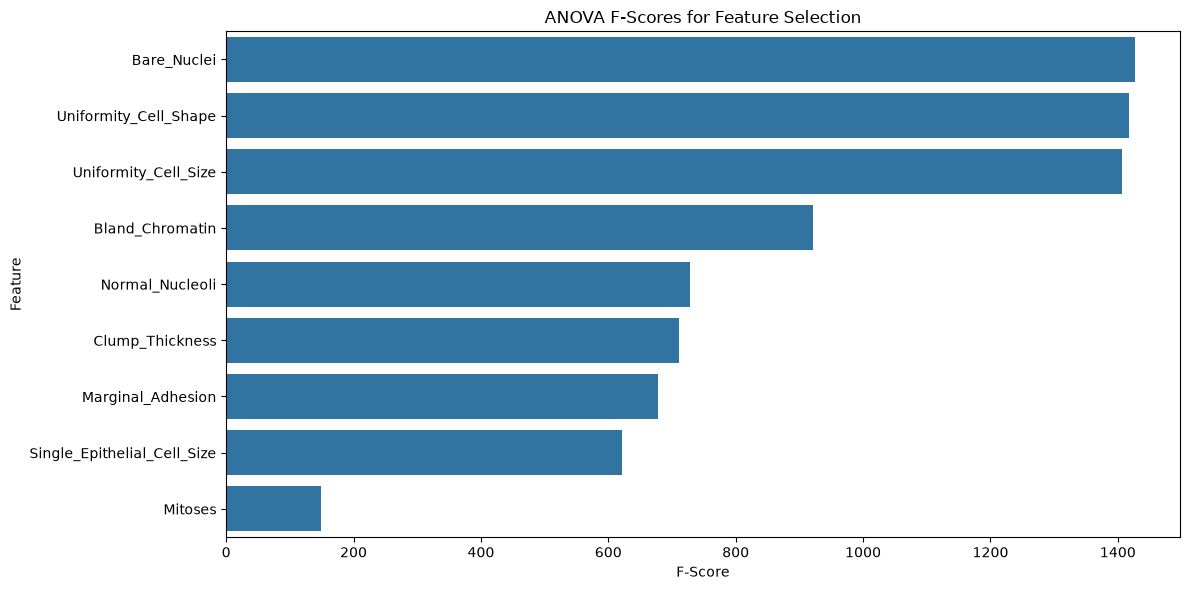

ANOVA plot saved to:
c:\Users\gayan\Documents\AI\results\eda_visualizations\anova_f_scores.png


In [21]:
# ============================================
# STEP 17.1 - Save the ANOVA visualization
# ============================================

# Create the shared EDA visualization folder
# from the main project directory.
EDA_DIR = (
    PROJECT_ROOT
    / "results"
    / "eda_visualizations"
)

# Create the folder if it does not already exist.
EDA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Create the full path for the ANOVA plot.
anova_plot_path = (
    EDA_DIR
    / "anova_f_scores.png"
)

# Create the ANOVA F-score bar chart.
plt.figure(figsize=(12, 6))

sns.barplot(
    data=feature_selection_results,
    x="F_Score",
    y="Feature"
)

# Add chart labels and title.
plt.title("ANOVA F-Scores for Feature Selection")
plt.xlabel("F-Score")
plt.ylabel("Feature")

# Adjust spacing before saving.
plt.tight_layout()

# Save the plot inside the shared EDA visualization folder.
plt.savefig(
    anova_plot_path,
    dpi=300,
    bbox_inches="tight"
)

# Display the plot.
plt.show()

# Confirm where the plot was saved.
print("ANOVA plot saved to:")
print(anova_plot_path)

# Member 3 Final Summary

## Target Encoding
The original target labels were:

- 2 = Benign
- 4 = Malignant

They were encoded as:

- 0 = Benign
- 1 = Malignant

## Outlier Analysis
Statistical outliers were identified using boxplots and the IQR method.

However, the feature values are within the valid 1–10 scoring range.
Therefore, valid statistical outliers were retained instead of being
automatically removed.

## Feature Selection
ANOVA F-test was used with a significance level of 0.05.

All nine predictive features had statistically significant p-values
below 0.05.

Therefore, all nine features were retained.

## Main Conclusion
The dataset contains potentially useful information across all nine
predictive features. No feature was removed using the ANOVA significance
criterion, while PCA was later used separately for dimensionality
reduction.

# Final Evaluation – Individual Model

## Member 03 – Random Forest Classification

### Objective

The objective of this section is to develop a Random Forest classification
model to classify breast cancer cases as:

- 0 = Benign
- 1 = Malignant

Random Forest is an ensemble learning algorithm that combines predictions
from multiple decision trees. Each tree is trained using a different sample
of the training data and a subset of features. The final classification is
based on the combined predictions of the trees.

Random Forest is suitable for this dataset because:

- The problem is a binary classification problem.
- The dataset contains numerical predictive features.
- It can model non-linear relationships between features and the target.
- It is less sensitive to individual noisy observations than a single
  Decision Tree.
- It can provide feature importance values.

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

Recall is particularly important because a false negative represents a
malignant case incorrectly classified as benign.

In [22]:
# ============================================================
# IMPORT LIBRARIES FOR RANDOM FOREST MODELLING
# ============================================================

# NumPy is used for numerical operations.
import numpy as np

# Pandas is used for DataFrames and result tables.
import pandas as pd

# Matplotlib is used for plots and visualizations.
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# MODEL SELECTION TOOLS
# ------------------------------------------------------------

# train_test_split:
# Divides the dataset into training and testing sets.
#
# StratifiedKFold:
# Creates cross-validation folds while preserving class proportions.
#
# cross_validate:
# Evaluates a model using several metrics across multiple folds.
#
# GridSearchCV:
# Tests different hyperparameter combinations automatically.
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)


# ------------------------------------------------------------
# PREPROCESSING AND PIPELINE
# ------------------------------------------------------------

# Pipeline keeps preprocessing and modelling steps together.
from sklearn.pipeline import Pipeline

# SimpleImputer is used to replace missing values.
from sklearn.impute import SimpleImputer


# ------------------------------------------------------------
# RANDOM FOREST MODEL
# ------------------------------------------------------------

# RandomForestClassifier creates an ensemble of Decision Trees.
from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# EVALUATION METRICS
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


# Confirm that the imports were successful.
print("Random Forest libraries imported successfully.")

Random Forest libraries imported successfully.


In [23]:
# ============================================================
# CHECK MEMBER 03'S CURRENT DATAFRAME
# ============================================================

# Display the number of rows and columns currently in df.
print("Current df shape:", df.shape)

# Display all current column names.
# This allows us to identify any columns created during
# Member 03's existing feature-selection or target-encoding work.
print("\nCurrent columns:")
print(df.columns.tolist())

# Display the original target distribution if Class still exists.
if "Class" in df.columns:
    print("\nCurrent Class distribution:")
    print(df["Class"].value_counts().sort_index())

# Check the number of exact duplicate rows currently present.
print("\nExact duplicate rows:")
print(df.duplicated().sum())

Current df shape: (699, 11)

Current columns:
['Sample_ID', 'Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']

Current Class distribution:
Class
2    458
4    241
Name: count, dtype: int64

Exact duplicate rows:
8


In [24]:
# ============================================================
# CHECK VARIABLES CREATED BY MEMBER 03'S EXISTING WORK
# ============================================================

# Check whether common modelling variables already exist.
# This does not change any data.
#
# It only tells us which objects are currently available
# after running Member 03's existing notebook.

variables_to_check = [
    "X",
    "y",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "selected_features",
    "selected_feature_names",
    "model_df"
]

print("Existing Member 03 variables:")
print("-" * 45)

for variable_name in variables_to_check:

    # globals() contains variables currently available
    # in the Jupyter Notebook session.
    if variable_name in globals():

        variable = globals()[variable_name]

        # If the object has a shape, display it.
        if hasattr(variable, "shape"):
            print(
                f"{variable_name:25s} -> EXISTS, "
                f"shape = {variable.shape}"
            )

        # Otherwise simply confirm that it exists.
        else:
            print(
                f"{variable_name:25s} -> EXISTS"
            )

    else:
        print(
            f"{variable_name:25s} -> NOT FOUND"
        )

Existing Member 03 variables:
---------------------------------------------
X                         -> EXISTS, shape = (699, 9)
y                         -> EXISTS, shape = (699,)
X_train                   -> NOT FOUND
X_test                    -> NOT FOUND
y_train                   -> NOT FOUND
y_test                    -> NOT FOUND
selected_features         -> EXISTS
selected_feature_names    -> NOT FOUND
model_df                  -> NOT FOUND


In [25]:
# ============================================================
# CREATE A CLEAN DATASET FOR RANDOM FOREST MODELLING
# ============================================================

# Create a separate copy of the original dataframe.
# This prevents the existing Member 03 feature-selection and
# ANOVA work from being modified.
model_df = df.copy()


# Remove exact duplicate observations.
#
# The original dataset contains 699 observations and
# 8 exact duplicate rows.
#
# keep="first" keeps the first occurrence of each duplicated
# observation and removes the later identical copy.
model_df = model_df.drop_duplicates(
    keep="first"
).reset_index(drop=True)


# Display the shape of the cleaned modelling dataset.
print("Final modelling dataset shape:", model_df.shape)


# Confirm that no exact duplicate observations remain.
print(
    "Remaining duplicate rows:",
    model_df.duplicated().sum()
)


# Display the target distribution after duplicate removal.
print("\nClass distribution:")

print(
    model_df["Class"]
    .value_counts()
    .sort_index()
)

Final modelling dataset shape: (691, 11)
Remaining duplicate rows: 0

Class distribution:
Class
2    453
4    238
Name: count, dtype: int64


In [26]:
# ============================================================
# PREPARE FEATURES (X) AND TARGET (y)
# ============================================================

# Create the feature matrix.
#
# Sample_ID is excluded because it is only an identifier.
# It does not represent a biological characteristic of
# the breast-cancer sample.
#
# Class is excluded because it is the target that the
# Random Forest model must predict.
X = model_df.drop(
    columns=["Sample_ID", "Class"]
).copy()


# Convert the original class labels into binary values.
#
# Original:
# 2 = Benign
# 4 = Malignant
#
# New:
# 0 = Benign
# 1 = Malignant
y = model_df["Class"].map({
    2: 0,
    4: 1
})


# Display the dimensions of the final feature matrix
# and target vector.
print("X shape:", X.shape)
print("y shape:", y.shape)


# Display the binary target distribution.
print("\nTarget distribution:")

print(
    y.value_counts()
    .sort_index()
)


# Make sure target encoding did not create missing values.
print(
    "\nMissing target values:",
    y.isna().sum()
)


# Display all predictors used by Random Forest.
print("\nFeatures used for modelling:")

print(
    X.columns.tolist()
)

X shape: (691, 9)
y shape: (691,)

Target distribution:
Class
0    453
1    238
Name: count, dtype: int64

Missing target values: 0

Features used for modelling:
['Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses']


### Relationship with Member 03 Feature Selection

Member 03 previously evaluated the predictive features using ANOVA-based
feature selection.

The feature-selection analysis indicated that all nine predictive features
provided statistically significant information for distinguishing the target
classes. Therefore, all nine predictive features are retained for the Random
Forest model.

`Sample_ID` is excluded because it is an identifier rather than a predictive
tumour characteristic.

In [27]:
# ============================================================
# VERIFY THE FEATURES USED BY RANDOM FOREST
# ============================================================

# Store the final predictor names used in the individual model.
#
# The previous ANOVA analysis retained the predictive features,
# so all nine biological/cellular features are used here.
rf_features = X.columns.tolist()


# Display the number of retained predictive features.
print(
    "Number of features used:",
    len(rf_features)
)


# Display each feature clearly.
print("\nFeatures used by Random Forest:")

for number, feature in enumerate(
    rf_features,
    start=1
):
    print(f"{number}. {feature}")

Number of features used: 9

Features used by Random Forest:
1. Clump_Thickness
2. Uniformity_Cell_Size
3. Uniformity_Cell_Shape
4. Marginal_Adhesion
5. Single_Epithelial_Cell_Size
6. Bare_Nuclei
7. Bland_Chromatin
8. Normal_Nucleoli
9. Mitoses


In [28]:
# ============================================================
# CREATE TRAINING AND TESTING DATASETS
# ============================================================

# Split the cleaned dataset into:
#
# 80% -> training data
# 20% -> testing data
#
# random_state=42:
# Makes the split reproducible.
#
# stratify=y:
# Preserves approximately the same benign/malignant
# proportion in both training and testing datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# VERIFY THE SPLIT
# ============================================================

# Display total number of observations.
print(
    "Full dataset :",
    len(X)
)


# Display training dimensions.
print(
    "Training set :",
    X_train.shape
)


# Display testing dimensions.
print(
    "Testing set  :",
    X_test.shape
)


# Display training target distribution.
print("\nTraining target distribution:")

print(
    y_train.value_counts()
    .sort_index()
)


# Display testing target distribution.
print("\nTesting target distribution:")

print(
    y_test.value_counts()
    .sort_index()
)


# Confirm that no observations were lost during splitting.
print(
    "\nTrain + Test :",
    len(X_train) + len(X_test)
)

Full dataset : 691
Training set : (552, 9)
Testing set  : (139, 9)

Training target distribution:
Class
0    362
1    190
Name: count, dtype: int64

Testing target distribution:
Class
0    91
1    48
Name: count, dtype: int64

Train + Test : 691


## Baseline Random Forest Model

A baseline Random Forest model is first trained using the default
hyperparameters.

Random Forest creates multiple Decision Trees and combines their predictions.
This generally produces a more stable model than relying on a single tree.

Median imputation is included inside the pipeline to handle missing
`Bare_Nuclei` values.

Unlike KNN, feature scaling is not required for Random Forest because tree
splits are based on feature thresholds rather than distances.

In [29]:
# ============================================================
# CREATE BASELINE RANDOM FOREST PIPELINE
# ============================================================

# Create a pipeline containing preprocessing and the model.
#
# Keeping the imputer inside the pipeline ensures that missing
# values are handled using information from the training data
# rather than from the held-out test dataset.
random_forest_pipeline = Pipeline([

    # --------------------------------------------------------
    # STEP 1: MISSING-VALUE IMPUTATION
    # --------------------------------------------------------

    # Replace missing feature values using the median value
    # calculated from the training data.
    #
    # This is required because Bare_Nuclei contains missing
    # observations in the original dataset.
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),


    # --------------------------------------------------------
    # STEP 2: RANDOM FOREST CLASSIFIER
    # --------------------------------------------------------

    # Create the baseline Random Forest.
    #
    # random_state=42 makes the random behaviour reproducible.
    #
    # Other parameters remain at their default values so this
    # model acts as our baseline before tuning.
    (
        "model",
        RandomForestClassifier(
            random_state=42
        )
    )
])


# ============================================================
# TRAIN THE BASELINE MODEL
# ============================================================

# Fit the entire pipeline using only the training dataset.
random_forest_pipeline.fit(
    X_train,
    y_train
)


# Confirm successful training.
print(
    "Baseline Random Forest model trained successfully."
)

Baseline Random Forest model trained successfully.


In [30]:
# ============================================================
# BASELINE RANDOM FOREST TEST-SET PREDICTIONS
# ============================================================

# Predict the class of each test observation.
#
# Output:
# 0 -> Benign
# 1 -> Malignant
y_pred_rf_baseline = random_forest_pipeline.predict(
    X_test
)


# Obtain the predicted probability of the positive class.
#
# [:, 1] selects the probability that an observation
# belongs to Class 1 (Malignant).
y_prob_rf_baseline = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]


# ============================================================
# CALCULATE PERFORMANCE METRICS
# ============================================================

# Overall proportion of correct predictions.
rf_baseline_accuracy = accuracy_score(
    y_test,
    y_pred_rf_baseline
)


# Out of all predicted malignant cases,
# calculate how many were actually malignant.
rf_baseline_precision = precision_score(
    y_test,
    y_pred_rf_baseline
)


# Out of all actual malignant cases,
# calculate how many were correctly detected.
rf_baseline_recall = recall_score(
    y_test,
    y_pred_rf_baseline
)


# Calculate the balance between precision and recall.
rf_baseline_f1 = f1_score(
    y_test,
    y_pred_rf_baseline
)


# Evaluate how well the model separates benign and
# malignant cases across different thresholds.
rf_baseline_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf_baseline
)


# ============================================================
# DISPLAY BASELINE RESULTS
# ============================================================

print("Baseline Random Forest Test Results")
print("-" * 45)

print(
    f"Accuracy  : {rf_baseline_accuracy:.4f}"
)

print(
    f"Precision : {rf_baseline_precision:.4f}"
)

print(
    f"Recall    : {rf_baseline_recall:.4f}"
)

print(
    f"F1-score  : {rf_baseline_f1:.4f}"
)

print(
    f"ROC-AUC   : {rf_baseline_roc_auc:.4f}"
)

Baseline Random Forest Test Results
---------------------------------------------
Accuracy  : 0.9568
Precision : 0.9565
Recall    : 0.9167
F1-score  : 0.9362
ROC-AUC   : 0.9934


In [31]:
# ============================================================
# BASELINE RANDOM FOREST CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix.
rf_baseline_cm = confusion_matrix(
    y_test,
    y_pred_rf_baseline
)


# Display the complete matrix.
print(
    "Baseline Random Forest Confusion Matrix:"
)

print(
    rf_baseline_cm
)


# Extract the four confusion-matrix values.
#
# TN = benign correctly classified as benign
# FP = benign incorrectly classified as malignant
# FN = malignant incorrectly classified as benign
# TP = malignant correctly classified as malignant
tn_rf, fp_rf, fn_rf, tp_rf = (
    rf_baseline_cm.ravel()
)


# Display the individual values.
print("\nConfusion Matrix Details")
print("-" * 40)

print(
    "True Negatives  (TN):",
    tn_rf
)

print(
    "False Positives (FP):",
    fp_rf
)

print(
    "False Negatives (FN):",
    fn_rf
)

print(
    "True Positives  (TP):",
    tp_rf
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

# Display class-specific precision, recall and F1-score.
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf_baseline,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)

Baseline Random Forest Confusion Matrix:
[[89  2]
 [ 4 44]]

Confusion Matrix Details
----------------------------------------
True Negatives  (TN): 89
False Positives (FP): 2
False Negatives (FN): 4
True Positives  (TP): 44

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.98      0.97        91
   Malignant       0.96      0.92      0.94        48

    accuracy                           0.96       139
   macro avg       0.96      0.95      0.95       139
weighted avg       0.96      0.96      0.96       139



In [32]:
# ============================================================
# CREATE STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

# Divide the training data into five folds.
#
# Stratification preserves approximately the same
# benign/malignant ratio in every fold.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# DEFINE CROSS-VALIDATION METRICS
# ============================================================

# Evaluate the model using the same metrics used for
# the other members' individual models.
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


# ============================================================
# PERFORM CROSS-VALIDATION
# ============================================================

# Evaluate the complete Random Forest pipeline using only
# the training dataset.
#
# The held-out test dataset is not used here.
cv_results_rf = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)


# ============================================================
# DISPLAY CROSS-VALIDATION RESULTS
# ============================================================

print(
    "Baseline Random Forest - 5-Fold Cross-Validation"
)

print("-" * 55)


# Display the mean and standard deviation of each metric
# across the five validation folds.
for metric in scoring.keys():

    # Retrieve the five scores for the current metric.
    scores = cv_results_rf[
        f"test_{metric}"
    ]

    # Display average performance and variation.
    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± "
        f"{scores.std():.4f}"
    )

Baseline Random Forest - 5-Fold Cross-Validation
-------------------------------------------------------
ACCURACY  : 0.9638 ± 0.0128
PRECISION : 0.9398 ± 0.0317
RECALL    : 0.9579 ± 0.0394
F1        : 0.9478 ± 0.0186
ROC_AUC   : 0.9919 ± 0.0038


## Random Forest Hyperparameter Tuning

The baseline Random Forest uses mostly default hyperparameters. To investigate
different varieties of the model and improve its performance, GridSearchCV is
used to test multiple hyperparameter combinations.

The following hyperparameters are investigated:

- **n_estimators** – Number of Decision Trees in the Random Forest.
- **max_depth** – Maximum depth allowed for each Decision Tree.
- **min_samples_split** – Minimum number of samples required to split an internal node.
- **min_samples_leaf** – Minimum number of samples required in a leaf node.
- **max_features** – Number of features considered when searching for the best split.
- **class_weight** – Controls whether additional importance is given to the minority class.

The models are compared using **F1-score** during 5-fold stratified
cross-validation because F1 provides a balance between precision and recall.

In [33]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER GRID
# ============================================================

# Define different values for the main Random Forest
# hyperparameters.
#
# GridSearchCV will create different Random Forest varieties
# using combinations of these values.
rf_param_grid = {

    # Number of Decision Trees in the forest.
    "model__n_estimators": [
        100,
        200
    ],

    # Maximum depth of each Decision Tree.
    #
    # None means that a tree may continue growing until
    # another stopping condition is reached.
    "model__max_depth": [
        None,
        5,
        10
    ],

    # Minimum number of observations required to split
    # an internal tree node.
    "model__min_samples_split": [
        2,
        5
    ],

    # Minimum number of observations that must remain
    # inside a leaf node.
    "model__min_samples_leaf": [
        1,
        2
    ],

    # Number of features randomly considered at each split.
    #
    # "sqrt" considers approximately the square root
    # of the total number of features.
    #
    # None allows all features to be considered.
    "model__max_features": [
        "sqrt",
        None
    ],

    # None uses the original class distribution.
    #
    # "balanced" automatically adjusts class weights
    # according to the class frequencies.
    "model__class_weight": [
        None,
        "balanced"
    ]
}


# ============================================================
# CALCULATE NUMBER OF MODEL VARIETIES
# ============================================================

# Calculate the total number of hyperparameter combinations.
number_of_combinations = (
    len(rf_param_grid["model__n_estimators"])
    * len(rf_param_grid["model__max_depth"])
    * len(rf_param_grid["model__min_samples_split"])
    * len(rf_param_grid["model__min_samples_leaf"])
    * len(rf_param_grid["model__max_features"])
    * len(rf_param_grid["model__class_weight"])
)


print(
    "Random Forest configurations to test:",
    number_of_combinations
)


# Each configuration is evaluated using 5-fold
# cross-validation.
print(
    "Total model fits:",
    number_of_combinations * 5
)

Random Forest configurations to test: 96
Total model fits: 480


In [34]:
# ============================================================
# RANDOM FOREST GRID SEARCH
# ============================================================

# Create GridSearchCV.
#
# estimator:
# Uses our Random Forest pipeline containing median
# imputation and RandomForestClassifier.
#
# param_grid:
# Contains the different Random Forest configurations.
#
# scoring="f1":
# Selects the optimum configuration according to F1-score.
#
# cv=cv:
# Uses the same 5-fold StratifiedKFold created earlier.
#
# n_jobs=-1:
# Allows scikit-learn to use all available CPU cores.
#
# return_train_score=True:
# Stores training scores so that we can compare training
# and validation performance.
rf_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)


# Train and evaluate all Random Forest configurations
# using only the training dataset.
#
# The held-out test dataset is NOT used during tuning.
rf_grid_search.fit(
    X_train,
    y_train
)


# ============================================================
# DISPLAY THE OPTIMUM CONFIGURATION
# ============================================================

print("\nRandom Forest Grid Search Complete")
print("-" * 50)


# Display the hyperparameters selected by GridSearchCV.
print(
    "Best Parameters:"
)

print(
    rf_grid_search.best_params_
)


# Display the best average validation F1-score.
print(
    "\nBest Cross-Validation F1:",
    f"{rf_grid_search.best_score_:.4f}"
)

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Random Forest Grid Search Complete
--------------------------------------------------
Best Parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Cross-Validation F1: 0.9520


In [35]:
# ============================================================
# CONVERT GRID-SEARCH RESULTS TO A DATAFRAME
# ============================================================

# Store all 96 GridSearchCV results in a DataFrame.
rf_grid_results = pd.DataFrame(
    rf_grid_search.cv_results_
)


# Select the most useful columns for comparison.
rf_top_results = rf_grid_results[[
    "rank_test_score",
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "param_model__max_features",
    "param_model__class_weight",
    "mean_train_score",
    "mean_test_score",
    "std_test_score"
]].copy()


# Sort the configurations according to validation rank.
rf_top_results = rf_top_results.sort_values(
    by="rank_test_score"
)


# Display the ten highest-ranked configurations.
print(
    "Top 10 Random Forest Configurations:"
)

display(
    rf_top_results.head(10)
)

Top 10 Random Forest Configurations:


,rank_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__class_weight,mean_train_score,mean_test_score,std_test_score
69,1,200,5,2,2,sqrt,balanced,0.971884,0.951981,0.015683
71,1,200,5,5,2,sqrt,balanced,0.971884,0.951981,0.015683
68,3,100,5,2,2,sqrt,balanced,0.973122,0.949245,0.012534
67,3,200,5,5,1,sqrt,balanced,0.971873,0.949245,0.012534
64,5,100,5,2,1,sqrt,balanced,0.973122,0.949113,0.014520
65,6,200,5,2,1,sqrt,balanced,0.974367,0.948960,0.012590
17,7,200,5,2,1,sqrt,NaN,0.979392,0.948590,0.010633
19,8,200,5,5,1,sqrt,NaN,0.975583,0.948531,0.013566
22,9,100,5,5,2,sqrt,NaN,0.974924,0.948218,0.013814
0,10,100,None,2,1,sqrt,NaN,1.000000,0.947789,0.018632


In [36]:
# ============================================================
# DISPLAY EXACT BEST RANDOM FOREST CONFIGURATION
# ============================================================

# Print the exact hyperparameter combination selected
# by GridSearchCV.
print("Best Parameters:")
print(rf_grid_search.best_params_)


# Print the mean 5-fold validation F1-score achieved
# by the selected configuration.
print(
    "\nBest Cross-Validation F1:",
    f"{rf_grid_search.best_score_:.4f}"
)

Best Parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Cross-Validation F1: 0.9520


In [37]:
# ============================================================
# GET THE BEST TUNED RANDOM FOREST MODEL
# ============================================================

# GridSearchCV automatically stores the pipeline containing
# the hyperparameter combination with the highest validation
# F1-score.
#
# We use best_estimator_ instead of manually creating another
# Random Forest. This prevents us from accidentally copying
# any of the winning parameters incorrectly.
best_rf_model = rf_grid_search.best_estimator_


# Display the selected model.
print("Best tuned Random Forest model:")
print(best_rf_model)

Best tuned Random Forest model:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=2, n_estimators=200,
                                        random_state=42))])


In [38]:
# ============================================================
# TUNED RANDOM FOREST TEST-SET PREDICTIONS
# ============================================================

# Predict benign (0) or malignant (1) for the untouched
# held-out test dataset.
y_pred_rf_tuned = best_rf_model.predict(
    X_test
)


# Obtain the probability of the positive class:
# Class 1 = Malignant.
#
# These probabilities are required for ROC-AUC.
y_prob_rf_tuned = best_rf_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# CALCULATE TUNED MODEL METRICS
# ============================================================

# Calculate test accuracy.
rf_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_rf_tuned
)


# Calculate precision for the malignant class.
rf_tuned_precision = precision_score(
    y_test,
    y_pred_rf_tuned
)


# Calculate recall for the malignant class.
rf_tuned_recall = recall_score(
    y_test,
    y_pred_rf_tuned
)


# Calculate F1-score.
rf_tuned_f1 = f1_score(
    y_test,
    y_pred_rf_tuned
)


# Calculate ROC-AUC using predicted probabilities.
rf_tuned_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf_tuned
)


# ============================================================
# DISPLAY TUNED MODEL RESULTS
# ============================================================

print("Tuned Random Forest Test Results")
print("-" * 45)

print(
    f"Accuracy  : {rf_tuned_accuracy:.4f}"
)

print(
    f"Precision : {rf_tuned_precision:.4f}"
)

print(
    f"Recall    : {rf_tuned_recall:.4f}"
)

print(
    f"F1-score  : {rf_tuned_f1:.4f}"
)

print(
    f"ROC-AUC   : {rf_tuned_roc_auc:.4f}"
)

Tuned Random Forest Test Results
---------------------------------------------
Accuracy  : 0.9784
Precision : 0.9592
Recall    : 0.9792
F1-score  : 0.9691
ROC-AUC   : 0.9934


In [39]:
# ============================================================
# TUNED RANDOM FOREST CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix for the tuned model.
rf_tuned_cm = confusion_matrix(
    y_test,
    y_pred_rf_tuned
)


# Display the matrix.
print("Tuned Random Forest Confusion Matrix:")
print(rf_tuned_cm)


# Extract the four values from the confusion matrix.
#
# TN = Benign correctly predicted as benign
# FP = Benign incorrectly predicted as malignant
# FN = Malignant incorrectly predicted as benign
# TP = Malignant correctly predicted as malignant
tn_rf_tuned, fp_rf_tuned, fn_rf_tuned, tp_rf_tuned = (
    rf_tuned_cm.ravel()
)


# Display each value separately.
print("\nConfusion Matrix Details")
print("-" * 40)

print(
    "True Negatives  (TN):",
    tn_rf_tuned
)

print(
    "False Positives (FP):",
    fp_rf_tuned
)

print(
    "False Negatives (FN):",
    fn_rf_tuned
)

print(
    "True Positives  (TP):",
    tp_rf_tuned
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

# Show precision, recall and F1-score separately for
# benign and malignant cases.
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf_tuned,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)

Tuned Random Forest Confusion Matrix:
[[89  2]
 [ 1 47]]

Confusion Matrix Details
----------------------------------------
True Negatives  (TN): 89
False Positives (FP): 2
False Negatives (FN): 1
True Positives  (TP): 47

Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.98      0.98        91
   Malignant       0.96      0.98      0.97        48

    accuracy                           0.98       139
   macro avg       0.97      0.98      0.98       139
weighted avg       0.98      0.98      0.98       139



In [40]:
# ============================================================
# BASELINE VS TUNED RANDOM FOREST COMPARISON
# ============================================================

# Create a DataFrame containing the important test-set
# metrics for both Random Forest varieties.
rf_comparison = pd.DataFrame([

    # --------------------------------------------------------
    # BASELINE RANDOM FOREST
    # --------------------------------------------------------
    {
        "Model": "Random Forest - Baseline",
        "Accuracy": rf_baseline_accuracy,
        "Precision": rf_baseline_precision,
        "Recall": rf_baseline_recall,
        "F1": rf_baseline_f1,
        "ROC_AUC": rf_baseline_roc_auc,
        "False_Negatives": fn_rf
    },


    # --------------------------------------------------------
    # TUNED RANDOM FOREST
    # --------------------------------------------------------
    {
        "Model": "Random Forest - Tuned",
        "Accuracy": rf_tuned_accuracy,
        "Precision": rf_tuned_precision,
        "Recall": rf_tuned_recall,
        "F1": rf_tuned_f1,
        "ROC_AUC": rf_tuned_roc_auc,
        "False_Negatives": fn_rf_tuned
    }

])


# Round the metric values for easier reading.
rf_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
] = rf_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
].round(4)


# Display the final comparison.
print(
    "Baseline vs Tuned Random Forest Comparison:"
)

display(
    rf_comparison
)

Baseline vs Tuned Random Forest Comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,False_Negatives
0,Random Forest - Baseline,0.9568,0.9565,0.9167,0.9362,0.9934,4
1,Random Forest - Tuned,0.9784,0.9592,0.9792,0.9691,0.9934,1


In [41]:
# ============================================================
# TUNED RANDOM FOREST 5-FOLD CROSS-VALIDATION
# ============================================================

# Evaluate the selected tuned pipeline across the same
# five stratified folds.
#
# Only the training dataset is used here.
cv_results_rf_tuned = cross_validate(
    best_rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)


# ============================================================
# DISPLAY TUNED CROSS-VALIDATION RESULTS
# ============================================================

print(
    "Tuned Random Forest - 5-Fold Cross-Validation"
)

print("-" * 55)


# Display the mean and standard deviation for every metric.
for metric in scoring.keys():

    # Retrieve the five validation scores.
    scores = cv_results_rf_tuned[
        f"test_{metric}"
    ]

    # Display mean ± standard deviation.
    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± "
        f"{scores.std():.4f}"
    )

Tuned Random Forest - 5-Fold Cross-Validation
-------------------------------------------------------
ACCURACY  : 0.9656 ± 0.0121
PRECISION : 0.9233 ± 0.0375
RECALL    : 0.9842 ± 0.0211
F1        : 0.9520 ± 0.0157
ROC_AUC   : 0.9897 ± 0.0044


## Random Forest Feature Importance

Random Forest can estimate the relative importance of each feature based on
how much the feature contributes to reducing impurity across the Decision
Trees.

Feature importance helps us understand which variables contributed more
strongly to the model's predictions.

However, feature importance should not be interpreted as proving a causal
relationship between a feature and breast cancer.

In [42]:
# ============================================================
# EXTRACT RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# The best model is stored inside the pipeline under the
# step name "model".
tuned_rf_classifier = best_rf_model.named_steps["model"]


# Obtain the importance score calculated for each feature.
rf_feature_importance = tuned_rf_classifier.feature_importances_


# Create a DataFrame containing feature names and their
# corresponding importance values.
rf_feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_feature_importance
})


# Sort features from highest importance to lowest importance.
rf_feature_importance_df = rf_feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)


# Display the final feature-importance table.
print("Tuned Random Forest Feature Importance:")
display(rf_feature_importance_df)

Tuned Random Forest Feature Importance:


,Feature,Importance
0,Uniformity_Cell_Size,0.307685
1,Uniformity_Cell_Shape,0.256717
2,Bare_Nuclei,0.157222
3,Normal_Nucleoli,0.087858
4,Single_Epithelial_Cell_Size,0.074110
5,Bland_Chromatin,0.051049
6,Clump_Thickness,0.038295
7,Marginal_Adhesion,0.022333
8,Mitoses,0.004731


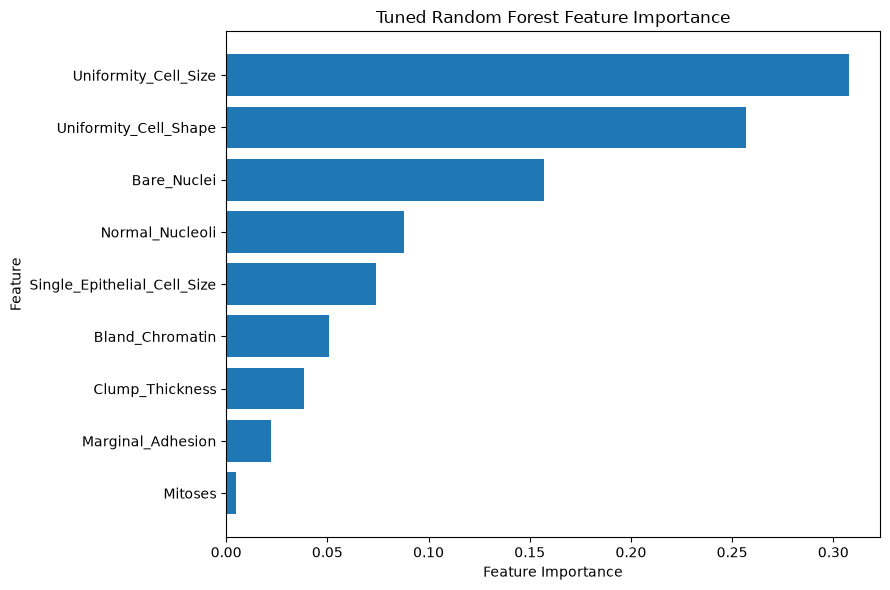

In [43]:
# ============================================================
# PLOT RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Create a horizontal bar chart.
plt.figure(figsize=(9, 6))


# Plot the importance of each feature.
plt.barh(
    rf_feature_importance_df["Feature"],
    rf_feature_importance_df["Importance"]
)


# Put the most important feature at the top.
plt.gca().invert_yaxis()


# Add chart labels and title.
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Tuned Random Forest Feature Importance")


# Improve spacing.
plt.tight_layout()


# Display the chart.
plt.show()

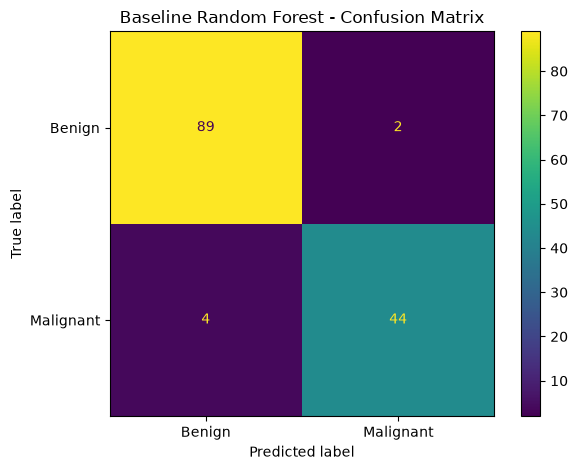

In [44]:
# ============================================================
# BASELINE RANDOM FOREST CONFUSION MATRIX PLOT
# ============================================================

# Create the confusion-matrix display using the predictions
# produced by the baseline Random Forest.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_baseline,
    display_labels=["Benign", "Malignant"]
)


# Add a descriptive title.
plt.title(
    "Baseline Random Forest - Confusion Matrix"
)


# Improve spacing and display the figure.
plt.tight_layout()
plt.show()

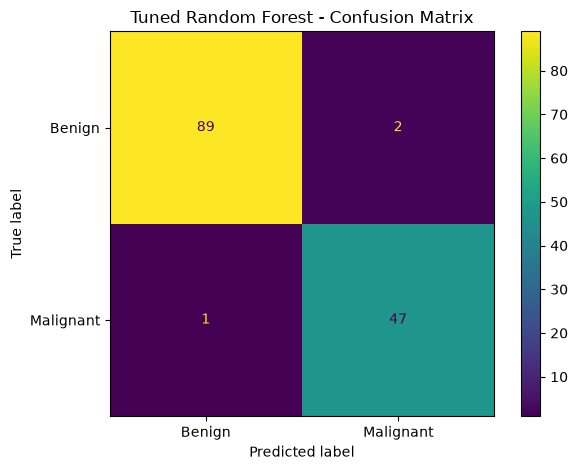

In [45]:
# ============================================================
# TUNED RANDOM FOREST CONFUSION MATRIX PLOT
# ============================================================

# Create the confusion-matrix display using predictions
# from the tuned Random Forest.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_tuned,
    display_labels=["Benign", "Malignant"]
)


# Add a descriptive title.
plt.title(
    "Tuned Random Forest - Confusion Matrix"
)


# Improve spacing and display the figure.
plt.tight_layout()
plt.show()

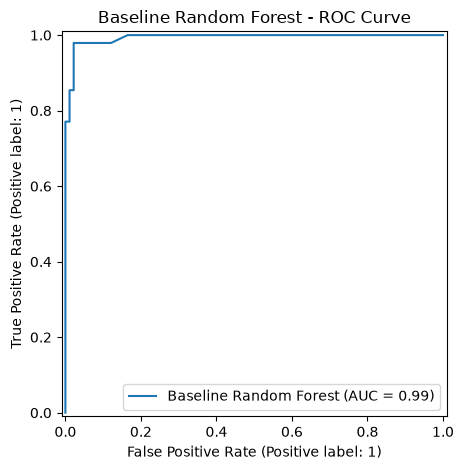

In [46]:
# ============================================================
# BASELINE RANDOM FOREST ROC CURVE
# ============================================================

# Plot the ROC curve using the true test labels and the
# baseline model's malignant-class probabilities.
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf_baseline,
    name="Baseline Random Forest"
)


# Add a descriptive title.
plt.title(
    "Baseline Random Forest - ROC Curve"
)


# Improve spacing and display the plot.
plt.tight_layout()
plt.show()

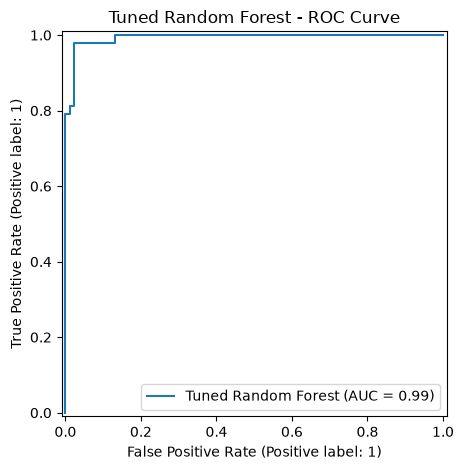

In [47]:
# ============================================================
# TUNED RANDOM FOREST ROC CURVE
# ============================================================

# Plot the ROC curve using the true test labels and the
# tuned model's malignant-class probabilities.
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf_tuned,
    name="Tuned Random Forest"
)


# Add a descriptive title.
plt.title(
    "Tuned Random Forest - ROC Curve"
)


# Improve spacing and display the plot.
plt.tight_layout()
plt.show()

## Final Conclusion – Member 03 Random Forest

### Model Suitability

Random Forest was selected because the task is a binary classification
problem containing numerical predictive features. Random Forest can model
non-linear relationships and combines multiple Decision Trees to produce
more stable predictions than relying on a single tree.

### Preprocessing

The modelling dataset contained 691 observations after removing 8 exact
duplicate observations from the original 699 rows.

`Sample_ID` was excluded because it is an identifier rather than a
predictive tumour characteristic.

The original class labels were encoded as:

- 0 = Benign
- 1 = Malignant

Median imputation was included inside the modelling pipeline to handle
missing values without using information from the held-out test set.

Feature scaling was not required because Random Forest uses tree-based
splitting rather than distance calculations.

### Feature Selection

Member 03's previous ANOVA analysis found that the nine predictive features
provided statistically significant information for distinguishing the
classes. Therefore, all nine predictive features were retained for Random
Forest modelling.

### Validation Method

The cleaned dataset was divided using an 80/20 stratified train-test split:

- Training observations = 552
- Testing observations = 139

Five-fold Stratified Cross-Validation was performed on the training data.

### Hyperparameter Tuning

GridSearchCV evaluated 96 Random Forest hyperparameter configurations using
5-fold stratified cross-validation, resulting in 480 model fits.

The optimum configuration selected according to validation F1-score was:

- n_estimators = 200
- max_depth = 5
- max_features = sqrt
- min_samples_leaf = 2
- min_samples_split = 2
- class_weight = balanced

The best cross-validation F1-score during tuning was 0.9520.

### Tuned Cross-Validation Performance

The tuned Random Forest achieved:

- Accuracy = 0.9656 ± 0.0121
- Precision = 0.9233 ± 0.0375
- Recall = 0.9842 ± 0.0211
- F1-score = 0.9520 ± 0.0157
- ROC-AUC = 0.9897 ± 0.0044

Compared with the baseline cross-validation results, tuning increased recall
from 0.9579 to 0.9842 and F1-score from 0.9478 to 0.9520. Precision decreased,
showing a trade-off toward detecting a greater proportion of malignant cases.

The tuned Random Forest is retained as Member 03's optimum model for the
final group-model comparison.

### Limitations

- Random Forest is less interpretable than a single Decision Tree.
- Feature importance does not establish causal relationships.
- Performance is based on a relatively small historical dataset.
- Results from this dataset may not generalize to all patient populations.

### Possible Improvements

Future work could include:

- Testing additional Random Forest hyperparameters.
- Comparing different feature-selection strategies.
- Evaluating probability-threshold adjustments to study the trade-off
  between false negatives and false positives.
- Validating the model using larger and more diverse external datasets.

In [48]:
# ============================================================
# SAVE MEMBER 03 RANDOM FOREST RESULTS
# ============================================================

# Create a dedicated Member 03 folder inside the shared
# results/outputs directory required by the repository structure.
output_dir = (
    PROJECT_ROOT
    / "results"
    / "outputs"
    / "member_03"
)

# Create the directory if it does not already exist.
output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# SAVE BASELINE VS TUNED TEST RESULTS
# ------------------------------------------------------------

# Save the comparison of the baseline and tuned
# Random Forest models.
rf_comparison.to_csv(
    output_dir / "random_forest_baseline_vs_tuned.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE COMPLETE GRID-SEARCH RESULTS
# ------------------------------------------------------------

# Save results from all 96 tested hyperparameter configurations.
rf_grid_results.to_csv(
    output_dir / "random_forest_grid_search_results.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE TOP GRID-SEARCH CONFIGURATIONS
# ------------------------------------------------------------

# Save the strongest Random Forest configurations
# from the grid-search results.
rf_top_results.to_csv(
    output_dir / "random_forest_top_configurations.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE FEATURE IMPORTANCE
# ------------------------------------------------------------

# Save the Random Forest feature-importance ranking.
rf_feature_importance_df.to_csv(
    output_dir / "random_forest_feature_importance.csv",
    index=False
)


# ------------------------------------------------------------
# CREATE CROSS-VALIDATION SUMMARY
# ------------------------------------------------------------

# Create a list that will contain one row for the
# baseline model and one row for the tuned model.
cv_summary = []

# Process the baseline and tuned cross-validation results.
for model_name, results in [
    ("Random Forest - Baseline", cv_results_rf),
    ("Random Forest - Tuned", cv_results_rf_tuned)
]:

    # Start a new row with the model name.
    row = {
        "Model": model_name
    }

    # Store the mean and standard deviation
    # for every evaluation metric.
    for metric in scoring.keys():

        scores = results[f"test_{metric}"]

        row[f"{metric}_mean"] = scores.mean()
        row[f"{metric}_std"] = scores.std()

    # Add the completed row to the summary.
    cv_summary.append(row)


# Convert the cross-validation summary into a DataFrame.
rf_cv_summary = pd.DataFrame(
    cv_summary
)


# Save the cross-validation summary.
rf_cv_summary.to_csv(
    output_dir / "random_forest_cross_validation_summary.csv",
    index=False
)


# ------------------------------------------------------------
# CONFIRM SAVED FILES
# ------------------------------------------------------------

# Confirm that Member 03 results were saved successfully.
print("Member 03 results saved successfully.")
print("Output folder:", output_dir)

print("\nSaved files:")

# Display every file saved inside the Member 03 folder.
for file in output_dir.iterdir():
    print(file.name)

Member 03 results saved successfully.
Output folder: c:\Users\gayan\Documents\AI\results\outputs\member_03

Saved files:
random_forest_baseline_vs_tuned.csv
random_forest_cross_validation_summary.csv
random_forest_feature_importance.csv
random_forest_grid_search_results.csv
random_forest_top_configurations.csv


In [49]:
# ============================================
# CHECK TRAINED RANDOM FOREST OBJECTS
# ============================================

# Display variables whose names may contain the trained
# Random Forest, GridSearchCV, or tuned model.
for name in list(globals()):
    if any(word in name.lower() for word in ["forest", "grid", "best", "tuned"]):
        obj = globals()[name]
        print(name, "->", type(obj))

GridSearchCV -> <class 'abc.ABCMeta'>
RandomForestClassifier -> <class 'abc.ABCMeta'>
random_forest_pipeline -> <class 'sklearn.pipeline.Pipeline'>
rf_param_grid -> <class 'dict'>
rf_grid_search -> <class 'sklearn.model_selection._search.GridSearchCV'>
rf_grid_results -> <class 'pandas.DataFrame'>
best_rf_model -> <class 'sklearn.pipeline.Pipeline'>
y_pred_rf_tuned -> <class 'numpy.ndarray'>
y_prob_rf_tuned -> <class 'numpy.ndarray'>
rf_tuned_accuracy -> <class 'float'>
rf_tuned_precision -> <class 'float'>
rf_tuned_recall -> <class 'float'>
rf_tuned_f1 -> <class 'float'>
rf_tuned_roc_auc -> <class 'float'>
rf_tuned_cm -> <class 'numpy.ndarray'>
tn_rf_tuned -> <class 'numpy.int64'>
fp_rf_tuned -> <class 'numpy.int64'>
fn_rf_tuned -> <class 'numpy.int64'>
tp_rf_tuned -> <class 'numpy.int64'>
cv_results_rf_tuned -> <class 'dict'>
tuned_rf_classifier -> <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [50]:
# ============================================
# SAVE FINAL TUNED RANDOM FOREST PIPELINE
# ============================================

# Import joblib for saving the trained scikit-learn model.
import joblib

# Import Path for safe project folder handling.
from pathlib import Path

# Detect the current working directory.
CURRENT_DIR = Path.cwd()

# If the notebook is running inside the "notebooks" folder,
# move one level up to the main project folder.
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Create the models folder if it does not already exist.
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Define the final saved model path.
MODEL_PATH = MODEL_DIR / "random_forest_pipeline.pkl"

# Save the already-fitted tuned Random Forest pipeline.
joblib.dump(best_rf_model, MODEL_PATH)

# Confirm that the model was saved successfully.
print("Model saved successfully!")
print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

Model saved successfully!
Model path: c:\Users\gayan\Documents\AI\models\random_forest_pipeline.pkl
Model exists: True


In [51]:
# ============================================
# VERIFY SAVED RANDOM FOREST PIPELINE
# ============================================

# Import joblib to load the saved model.
import joblib

# Load the saved tuned Random Forest pipeline.
loaded_rf_model = joblib.load(MODEL_PATH)

# Display the loaded object type.
print("Model loaded successfully!")
print("Loaded model type:", type(loaded_rf_model))

# Display the complete pipeline so we can verify
# that preprocessing and the classifier were saved together.
print("\nSaved pipeline:")
print(loaded_rf_model)

Model loaded successfully!
Loaded model type: <class 'sklearn.pipeline.Pipeline'>

Saved pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=2, n_estimators=200,
                                        random_state=42))])


In [52]:
# ============================================
# VERIFY UI PREDICTION
# ============================================

# Import pandas to create the same single observation
# that was entered into the Streamlit application.
import pandas as pd

# Create the exact UI test input.
# All nine feature values are set to 5.
ui_test_input = pd.DataFrame(
    [[5, 5, 5, 5, 5, 5, 5, 5, 5]],
    columns=[
        "Clump_Thickness",
        "Uniformity_Cell_Size",
        "Uniformity_Cell_Shape",
        "Marginal_Adhesion",
        "Single_Epithelial_Cell_Size",
        "Bare_Nuclei",
        "Bland_Chromatin",
        "Normal_Nucleoli",
        "Mitoses"
    ]
)

# Use the original fitted best Random Forest pipeline
# from the notebook to make the prediction.
ui_test_prediction = best_rf_model.predict(ui_test_input)[0]

# Get the class probabilities from the original model.
ui_test_probabilities = best_rf_model.predict_proba(ui_test_input)[0]

# Convert the numeric prediction into its class name.
ui_test_label = (
    "BENIGN"
    if ui_test_prediction == 0
    else "MALIGNANT"
)

# Display the results for comparison with the Streamlit UI.
print("Prediction:", ui_test_label)
print(
    "Benign probability:",
    f"{ui_test_probabilities[0] * 100:.2f}%"
)
print(
    "Malignant probability:",
    f"{ui_test_probabilities[1] * 100:.2f}%"
)

Prediction: MALIGNANT
Benign probability: 3.42%
Malignant probability: 96.58%
